In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("csv/dataset_iot.csv")

df.head()

,device,arquivo,total_packets,total_bytes,avg_packet_size,max_packet_size,min_packet_size,tcp_packets,udp_packets,dns_packets,...,unique_source_ips,unique_destination_ips,unique_ports,capture_duration,packets_per_second,bytes_per_second,tcp_ratio,udp_ratio,dns_ratio,icmp_ratio
0,google-home-mini,2021-09-02_15.50.20_192.168.12.128.pcap,33474,3115439,93.070413,1484,62,2568,29590,834,...,29,31,328,10218.833553,3.275716,304.872272,0.076716,0.883970,0.024915,0.039314
1,google-home-mini,2021-09-06_15.50.20_192.168.12.128.pcap,209059,22187779,106.131661,1484,54,54002,143960,7024,...,43,46,2592,86400.516961,2.419650,256.801461,0.258310,0.688609,0.033598,0.053038
2,google-home-mini,2021-09-07_15.50.20_192.168.12.128.pcap,52013,11839414,227.624132,1484,54,24396,17841,6214,...,45,49,2334,76169.694660,0.682857,155.434705,0.469037,0.343010,0.119470,0.187818
3,google-home-mini,2021-09-04_15.50.20_192.168.12.128.pcap,489973,41024647,83.728383,1514,54,147059,331820,7030,...,41,45,2586,86400.032354,5.670982,474.822125,0.300137,0.677221,0.014348,0.022626
4,google-home-mini,2021-09-05_15.50.20_192.168.12.128.pcap,352071,31586693,89.716827,1514,54,66000,275011,6988,...,43,47,2584,86399.138360,4.074936,365.590370,0.187462,0.781124,0.019848,0.031391


In [3]:
df = pd.read_csv("/home/emanuele/Documentos/ProjetosFaculdade/ProjetoIoT/csv/dataset_iot.csv")

In [4]:
print(df.shape)
df.info()

(297, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   device                  297 non-null    object 
 1   arquivo                 297 non-null    object 
 2   total_packets           297 non-null    int64  
 3   total_bytes             297 non-null    int64  
 4   avg_packet_size         297 non-null    float64
 5   max_packet_size         297 non-null    int64  
 6   min_packet_size         297 non-null    int64  
 7   tcp_packets             297 non-null    int64  
 8   udp_packets             297 non-null    int64  
 9   dns_packets             297 non-null    int64  
 10  icmp_packets            297 non-null    int64  
 11  arp_packets             297 non-null    int64  
 12  unique_source_ips       297 non-null    int64  
 13  unique_destination_ips  297 non-null    int64  
 14  unique_ports            297 non-

In [5]:
colunas_numericas = [
    "total_packets",
    "total_bytes",
    "avg_packet_size",
    "max_packet_size",
    "min_packet_size",
    "tcp_packets",
    "udp_packets",
    "dns_packets",
    "icmp_packets",
    "arp_packets",
    "unique_source_ips",
    "unique_destination_ips",
    "unique_ports",
    "capture_duration",
    "packets_per_second",
    "bytes_per_second",
    "tcp_ratio",
    "udp_ratio",
    "dns_ratio",
    "icmp_ratio"
]

X = df[colunas_numericas]

X.head()

,total_packets,total_bytes,avg_packet_size,max_packet_size,min_packet_size,tcp_packets,udp_packets,dns_packets,icmp_packets,arp_packets,unique_source_ips,unique_destination_ips,unique_ports,capture_duration,packets_per_second,bytes_per_second,tcp_ratio,udp_ratio,dns_ratio,icmp_ratio
0,33474,3115439,93.070413,1484,62,2568,29590,834,1316,0,29,31,328,10218.833553,3.275716,304.872272,0.076716,0.883970,0.024915,0.039314
1,209059,22187779,106.131661,1484,54,54002,143960,7024,11088,0,43,46,2592,86400.516961,2.419650,256.801461,0.258310,0.688609,0.033598,0.053038
2,52013,11839414,227.624132,1484,54,24396,17841,6214,9769,0,45,49,2334,76169.694660,0.682857,155.434705,0.469037,0.343010,0.119470,0.187818
3,489973,41024647,83.728383,1514,54,147059,331820,7030,11086,0,41,45,2586,86400.032354,5.670982,474.822125,0.300137,0.677221,0.014348,0.022626
4,352071,31586693,89.716827,1514,54,66000,275011,6988,11052,0,43,47,2584,86399.138360,4.074936,365.590370,0.187462,0.781124,0.019848,0.031391


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
inertia = []

K = range(2, 11)

for k in K:
    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo.fit(X_scaled)

    inertia.append(modelo.inertia_)

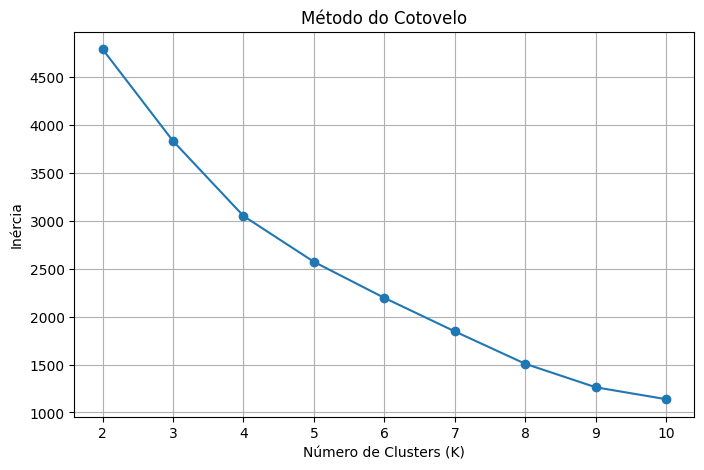

In [8]:
plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.title("Método do Cotovelo")

plt.xlabel("Número de Clusters (K)")

plt.ylabel("Inércia")

plt.grid(True)

plt.show()

In [9]:
silhouette_scores = []

for k in K:

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = modelo.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

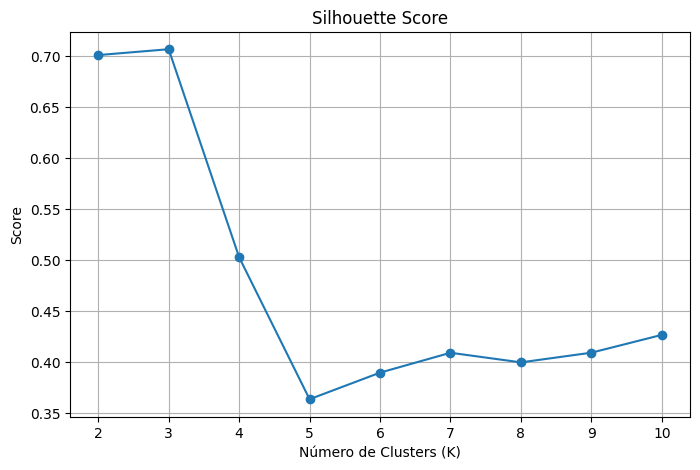

In [10]:
plt.figure(figsize=(8,5))

plt.plot(K, silhouette_scores, marker='o')

plt.title("Silhouette Score")

plt.xlabel("Número de Clusters (K)")

plt.ylabel("Score")

plt.grid(True)

plt.show()

In [11]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X_scaled)

In [12]:
df["cluster"].value_counts()

cluster
0    290
2      6
1      1
Name: count, dtype: int64

In [13]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

print("Silhouette:", silhouette_score(X_scaled, df["cluster"]))
print("Davies-Bouldin:", davies_bouldin_score(X_scaled, df["cluster"]))
print("Calinski-Harabasz:", calinski_harabasz_score(X_scaled, df["cluster"]))

Silhouette: 0.7069934203484922
Davies-Bouldin: 0.4207754913819408
Calinski-Harabasz: 80.77770632193723


In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

df[["PCA1", "PCA2", "cluster"]].head()

,PCA1,PCA2,cluster
0,-0.785580,-0.622404,0
1,2.451814,-1.813197,0
2,0.887360,-0.753234,0
3,5.705743,-2.754998,0
4,3.898771,-2.531737,0


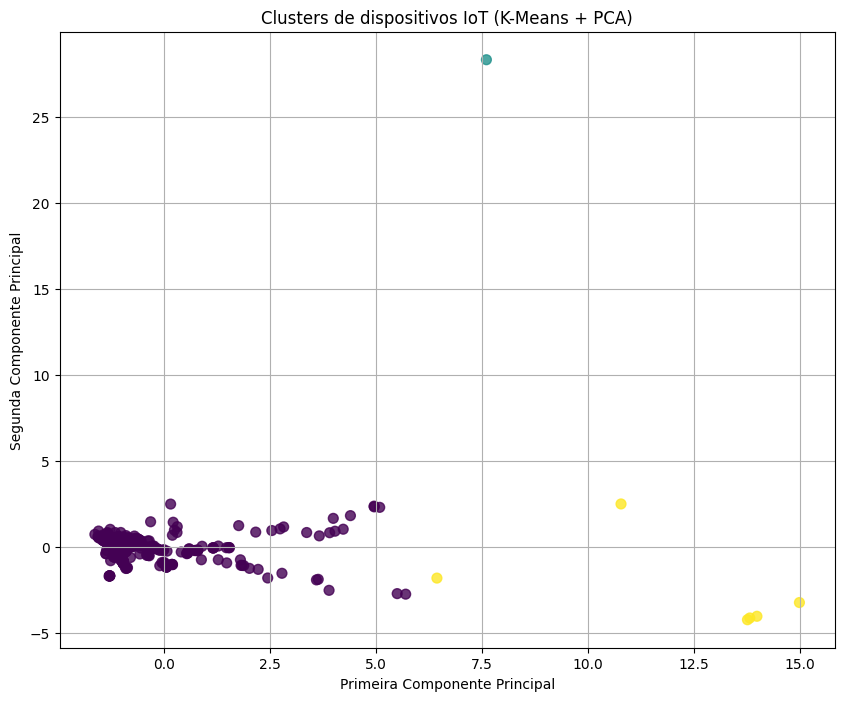

In [16]:
plt.figure(figsize=(10,8))

plt.scatter(
    df["PCA1"],
    df["PCA2"],
    c=df["cluster"],
    s=50,
    alpha=0.8
)

plt.title("Clusters de dispositivos IoT (K-Means + PCA)")
plt.xlabel("Primeira Componente Principal")
plt.ylabel("Segunda Componente Principal")
plt.grid(True)

plt.show()

In [17]:
medias_clusters = (
    df.groupby("cluster")[colunas_numericas]
      .mean()
      .round(2)
)

medias_clusters

,total_packets,total_bytes,avg_packet_size,max_packet_size,min_packet_size,tcp_packets,udp_packets,dns_packets,icmp_packets,arp_packets,unique_source_ips,unique_destination_ips,unique_ports,capture_duration,packets_per_second,bytes_per_second,tcp_ratio,udp_ratio,dns_ratio,icmp_ratio
cluster,,,,,,,,,,,,,,,,,,,,
0,37069.14,8.456210e+06,211.19,3297.46,52.3,21825.64,11767.63,938.99,2907.72,147.54,40.07,41.53,738.23,72082.26,0.52,126.34,0.68,0.25,0.03,0.04
1,13845.00,1.277802e+08,9229.34,53634.00,66.0,13813.00,32.00,30.00,0.00,0.00,10.00,12.00,26.00,48.18,287.38,2652308.54,1.00,0.00,0.00,0.00
2,100764.17,4.439865e+07,517.41,20042.00,46.0,59858.50,39102.83,35648.33,0.00,0.00,1989.00,1991.17,14039.00,70223.78,1.44,820.92,0.59,0.40,0.36,0.00


In [18]:
medias_clusters

,total_packets,total_bytes,avg_packet_size,max_packet_size,min_packet_size,tcp_packets,udp_packets,dns_packets,icmp_packets,arp_packets,unique_source_ips,unique_destination_ips,unique_ports,capture_duration,packets_per_second,bytes_per_second,tcp_ratio,udp_ratio,dns_ratio,icmp_ratio
cluster,,,,,,,,,,,,,,,,,,,,
0,37069.14,8.456210e+06,211.19,3297.46,52.3,21825.64,11767.63,938.99,2907.72,147.54,40.07,41.53,738.23,72082.26,0.52,126.34,0.68,0.25,0.03,0.04
1,13845.00,1.277802e+08,9229.34,53634.00,66.0,13813.00,32.00,30.00,0.00,0.00,10.00,12.00,26.00,48.18,287.38,2652308.54,1.00,0.00,0.00,0.00
2,100764.17,4.439865e+07,517.41,20042.00,46.0,59858.50,39102.83,35648.33,0.00,0.00,1989.00,1991.17,14039.00,70223.78,1.44,820.92,0.59,0.40,0.36,0.00
